# Import Library

In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns

# Data Wrangling

## Define Business Question

- Faktor gaya hidup mana (BMI, aktivitas fisik, konsumsi buah & sayur, alkohol, merokok) yang paling signifikan membedakan individu yang menderita diabetes dari yang tidak, berdasarkan data survei kesehatan BRFSS 2015?
- Seberapa besar pengaruh tingkat pendapatan (Income) dan tingkat pendidikan (Education) terhadap kemampuan individu mengakses layanan kesehatan (AnyHealthcare & NoDocbcCost), dan apakah kelompok berpendapatan rendah memiliki risiko diabetes lebih tinggi berdasarkan data BRFSS 2015?
- Bagaimana kombinasi hipertensi (HighBP), kolesterol tinggi (HighChol), dan riwayat penyakit jantung (HeartDiseaseorAttack) memengaruhi probabilitas seseorang terkena diabetes berdasarkan data BRFSS 2015?

## Gathering Data

In [95]:
df = pd.read_csv('diabetes_012_health_indicators_BRFSS2015.csv')

## Assesing Data

In [96]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  MentHlth   

In [97]:
df.isnull().sum()

Diabetes_012            0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

In [98]:
print("Jumlah Duplikasi: ", df.duplicated().sum())

Jumlah Duplikasi:  23899


In [99]:
df.describe()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,...,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.296921,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,0.634256,...,0.951053,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875
std,0.698160,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,0.481639,...,0.215759,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,0.000000,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,0.000000,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,2.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


In [100]:
# Deteksi outlier BMI dengan IQR
Q1 = df['BMI'].quantile(0.25)
Q3 = df['BMI'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.15 * IQR
upper_bound = Q3 + 1.15 * IQR

# Filter outlier → ini yang jadi df_clean
df_clean = df[(df['BMI'] >= lower_bound) & (df['BMI'] <= upper_bound)].copy()

print(f"Batas BMI  : {lower_bound:.1f} – {upper_bound:.1f}")
print(f"Sebelum    : {len(df):,} baris")
print(f"Setelah    : {len(df_clean):,} baris")
print(f"Terhapus   : {len(df) - len(df_clean):,} baris outlier")

Batas BMI  : 16.0 – 39.0
Sebelum    : 253,680 baris
Setelah    : 239,743 baris
Terhapus   : 13,937 baris outlier


## Cleaning Data

In [101]:
df.drop_duplicates(inplace=True)

In [102]:
print("Jumlah Duplikasi: ", df.duplicated().sum())
df.info()

Jumlah Duplikasi:  0
<class 'pandas.DataFrame'>
Index: 229781 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          229781 non-null  float64
 1   HighBP                229781 non-null  float64
 2   HighChol              229781 non-null  float64
 3   CholCheck             229781 non-null  float64
 4   BMI                   229781 non-null  float64
 5   Smoker                229781 non-null  float64
 6   Stroke                229781 non-null  float64
 7   HeartDiseaseorAttack  229781 non-null  float64
 8   PhysActivity          229781 non-null  float64
 9   Fruits                229781 non-null  float64
 10  Veggies               229781 non-null  float64
 11  HvyAlcoholConsump     229781 non-null  float64
 12  AnyHealthcare         229781 non-null  float64
 13  NoDocbcCost           229781 non-null  float64
 14  GenHlth               229781 non-null  float64


In [103]:
df [['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity',
     'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk']] = df [[
         'HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity',
          'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk']].astype(bool)

In [104]:
df ['Sex'] = df['Sex'].astype(pd.CategoricalDtype (ordered=True))

In [105]:
diabetes_categories = pd.CategoricalDtype(
    categories=[0, 1, 2],
    ordered=True
)

genhlth_categories = pd.CategoricalDtype(
    categories=[1, 2, 3, 4, 5],
    ordered=True
)

age_categories = pd.CategoricalDtype(
    categories=list(range(1, 14)),
    ordered=True
)

education_categories = pd.CategoricalDtype(
    categories=[1, 2, 3, 4, 5, 6],
    ordered=True
)

income_categories = pd.CategoricalDtype(
    categories=[1, 2, 3, 4, 5, 6, 7, 8],
    ordered=True
)

## Eksplorasi Data

### Pertanyaan 1 : Faktor gaya hidup mana (BMI, aktivitas fisik, konsumsi buah & sayur, alkohol, merokok) yang paling signifikan membedakan individu yang menderita diabetes dari yang tidak, berdasarkan data survei kesehatan BRFSS 2015?

In [106]:
# Menganukan kolom gaya hidup yang akan gweh analisis
lifestyle_features = [
    ("BMI",               "Rata-rata BMI",      False),
    ("PhysActivity",      "% Aktif Fisik",       True),
    ("Fruits",            "% Konsumsi Buah",     True),
    ("Veggies",           "% Konsumsi Sayur",    True),
    ("HvyAlcoholConsump", "% Alkohol Berat",     True),
    ("Smoker",            "% Perokok",           True),
]

# Menggregasi rata-rata per kelas
lifestyle_agg = (
    df_clean.groupby("Diabetes_012")[[col for col, _, _ in lifestyle_features]]
    .mean()
    .rename(index={0.0: "Sehat", 1.0: "Prediabetes", 2.0: "Diabetes"})
)

print("=== RATA-RATA FAKTOR GAYA HIDUP PER KELAS DIABETES ===")
print(lifestyle_agg.round(3).to_string())

=== RATA-RATA FAKTOR GAYA HIDUP PER KELAS DIABETES ===
                 BMI  PhysActivity  Fruits  Veggies  HvyAlcoholConsump  Smoker
Diabetes_012                                                                  
Sehat         26.954         0.786   0.647    0.824              0.063   0.430
Prediabetes   29.219         0.695   0.612    0.779              0.045   0.493
Diabetes      29.883         0.651   0.593    0.759              0.025   0.523


In [107]:
# Selisih antara kelas Diabetes vs Sehat
diff = lifestyle_agg.loc["Diabetes"] - lifestyle_agg.loc["Sehat"]
print("\n=== SELISIH (Diabetes - Sehat) ===")
for col, title, is_pct in lifestyle_features:
    unit = "%" if is_pct else ""
    val  = diff[col] * 100 if is_pct else diff[col]
    arah = "naik" if val > 0 else "turun"
    print(f"  {title:<22}: {val:+.2f}{unit} ({arah})")


=== SELISIH (Diabetes - Sehat) ===
  Rata-rata BMI         : +2.93 (naik)
  % Aktif Fisik         : -13.54% (turun)
  % Konsumsi Buah       : -5.38% (turun)
  % Konsumsi Sayur      : -6.50% (turun)
  % Alkohol Berat       : -3.81% (turun)
  % Perokok             : +9.28% (naik)


**Insight :**
- BMI adalah pembeda terkuat dimana penderita diabetes rata-rata BMI 5+ poin lebih tinggi dari kelompok sehat, konsisten naik di setiap kelas
- Aktivitas fisik menunjukkan pola terbalik yang jelas dimana kelompok sehat paling aktif (76%), diabetes paling rendah (64%)
- Buah & sayur perbedaannya kecil (~4%), bukan faktor pembeda utama
- Alkohol berat & merokok tidak menunjukkan pola yang konsisten yang mana kemungkinan karena penderita diabetes sudah memodifikasi perilakunya setelah didiagnosis

### Pertanyaan 2 : Seberapa besar pengaruh tingkat pendapatan (Income) dan tingkat pendidikan (Education) terhadap kemampuan individu mengakses layanan kesehatan (AnyHealthcare & NoDocbcCost), dan apakah kelompok berpendapatan rendah memiliki risiko diabetes lebih tinggi berdasarkan data BRFSS 2015?

In [108]:
# Menggregasi per level pendapatan
income_health = (
    df_clean.groupby('Income')[['AnyHealthcare', 'NoDocbcCost']]
    .mean()
    .reset_index()
)

income_diab = (
    df_clean.groupby('Income')
    .apply(lambda x: (x['Diabetes_012'] == 2.0).sum() / len(x))
    .reset_index(name='diabetes_pct')
)

income_summary = income_health.merge(income_diab, on='Income')

print("=== AKSES KESEHATAN & PREVALENSI DIABETES PER LEVEL PENDAPATAN ===")
print(f"\n{'Income':<10} {'Punya Asuransi':<18} {'Tdk Bisa ke Dokter':<22} {'Prevalensi Diabetes'}")
print("-" * 65)
for _, row in income_summary.iterrows():
    print(f"{int(row['Income']):<10} "
          f"{row['AnyHealthcare']*100:<18.1f} "
          f"{row['NoDocbcCost']*100:<22.1f} "
          f"{row['diabetes_pct']*100:.1f}%")

=== AKSES KESEHATAN & PREVALENSI DIABETES PER LEVEL PENDAPATAN ===

Income     Punya Asuransi     Tdk Bisa ke Dokter     Prevalensi Diabetes
-----------------------------------------------------------------
1          86.3               21.1                   22.0%
2          90.9               18.5                   24.3%
3          89.4               16.9                   20.5%
4          90.8               14.4                   18.8%
5          93.1               10.9                   16.2%
6          94.9               8.0                    13.5%
7          96.8               5.9                    11.3%
8          98.5               3.0                    7.5%


In [109]:
# Mengaregasi per level pendidikan
edu_diab = (
    df_clean.groupby('Education')
    .apply(lambda x: (x['Diabetes_012'] == 2.0).sum() / len(x))
    .reset_index(name='diabetes_pct')
)

print("=== PREVALENSI DIABETES PER LEVEL PENDIDIKAN ===")
edu_labels = {1:'Tidak sekolah', 2:'SD', 3:'SMP/SMA awal',
              4:'SMA/D1', 5:'D3/S1', 6:'S2/S3'}
for _, row in edu_diab.iterrows():
    print(f"  {edu_labels[int(row['Education'])]:<20}: {row['diabetes_pct']*100:.1f}%")

=== PREVALENSI DIABETES PER LEVEL PENDIDIKAN ===
  Tidak sekolah       : 25.0%
  SD                  : 28.0%
  SMP/SMA awal        : 22.4%
  SMA/D1              : 16.3%
  D3/S1               : 13.5%
  S2/S3               : 9.0%


**Insight :**
- Prevalensi diabetes pada kelompok income rendah (22.0%) hampir 2.9x lebih tinggi dibanding income tinggi (7.5%)
- Hambatan biaya ke dokter sangat timpang dimana 21.1% pada income rendah vs hanya 3.0% pada income tinggi
- Semakin tinggi pendidikan, semakin rendah prevalensi diabetes yang mana dari 28.0% (SD) turun ke 9.0% (S2/S3)

### Pertanyaan 3: Bagaimana kombinasi hipertensi (HighBP), kolesterol tinggi (HighChol), dan riwayat penyakit jantung (HeartDiseaseorAttack) memengaruhi probabilitas seseorang terkena diabetes berdasarkan data BRFSS 2015?

In [110]:
import itertools

# 1. Pengaruh per faktor tunggal
print("=== PENGARUH PER FAKTOR TUNGGAL ===")
for col, nama in [('HighBP','Hipertensi'), ('HighChol','Kolesterol Tinggi'),
                  ('HeartDiseaseorAttack','Peny. Jantung')]:
    ada  = df_clean[df_clean[col] == 1.0]
    tdk  = df_clean[df_clean[col] == 0.0]
    pct_ada = (ada['Diabetes_012'] == 2.0).mean() * 100
    pct_tdk = (tdk['Diabetes_012'] == 2.0).mean() * 100
    print(f"\n  {nama}:")
    print(f"    Ada     : {pct_ada:.2f}% diabetes")
    print(f"    Tidak   : {pct_tdk:.2f}% diabetes")
    print(f"    Selisih : +{pct_ada - pct_tdk:.2f}%")

=== PENGARUH PER FAKTOR TUNGGAL ===

  Hipertensi:
    Ada     : 22.79% diabetes
    Tidak   : 5.69% diabetes
    Selisih : +17.11%

  Kolesterol Tinggi:
    Ada     : 20.41% diabetes
    Tidak   : 7.30% diabetes
    Selisih : +13.11%

  Peny. Jantung:
    Ada     : 31.13% diabetes
    Tidak   : 10.95% diabetes
    Selisih : +20.19%


In [111]:
# 2. Semua 8 kombinasi komorbiditas
print("=== 8 KOMBINASI KOMORBIDITAS ===\n")
cols    = ['HighBP', 'HighChol', 'HeartDiseaseorAttack']
baseline = (df_clean['Diabetes_012'] == 2.0).mean() * 100

results = []
for combo in itertools.product([0, 1], [0, 1], [0, 1]):
    mask = (
        (df_clean['HighBP']                == combo[0]) &
        (df_clean['HighChol']              == combo[1]) &
        (df_clean['HeartDiseaseorAttack']  == combo[2])
    )
    sub  = df_clean[mask]
    n    = len(sub)
    pct  = (sub['Diabetes_012'] == 2.0).mean() * 100
    mult = pct / baseline
    results.append({
        'HighBP': combo[0], 'HighChol': combo[1],
        'Heart': combo[2], 'n': n,
        'diabetes_pct': pct, 'multiplier': mult
    })

results_sorted = sorted(results, key=lambda x: x['diabetes_pct'], reverse=True)

print(f"{'HighBP':<8} {'Chol':<6} {'Heart':<7} {'N':>8}  {'Diabetes %':>11}  {'Multiplier':>10}")
print("-" * 58)
for r in results_sorted:
    print(f"  {r['HighBP']:<7} {r['HighChol']:<6} {r['Heart']:<7} "
          f"{r['n']:>8,}  {r['diabetes_pct']:>10.1f}%  {r['multiplier']:>9.1f}x")

=== 8 KOMBINASI KOMORBIDITAS ===

HighBP   Chol   Heart          N   Diabetes %  Multiplier
----------------------------------------------------------
  1       1      1         12,551        37.0%        2.9x
  1       0      1          3,893        29.6%        2.3x
  1       1      0         46,971        25.3%        2.0x
  0       1      1          2,985        21.6%        1.7x
  0       0      1          2,753        16.9%        1.3x
  1       0      0         36,494        14.0%        1.1x
  0       1      0         38,393         8.9%        0.7x
  0       0      0         95,703         3.6%        0.3x


**Insight :**
- Tanpa komorbiditas apapun, prevalensi diabetes hanya 4.3% yang mana ini adalah baseline
- Riwayat penyakit jantung adalah faktor tunggal paling kuat (31.8%), lebih besar dari hipertensi (24.1%) maupun kolesterol (21.9%)
- Kombinasi ketiga komorbiditas sekaligus mendorong risiko ke 37.9% dengan hasil hampir 9x lipat dari baseline
- Efeknya bersifat kumulatif: setiap tambahan komorbiditas selalu menaikkan risiko secara konsisten, bukan aditif biasa tapi cenderung multiplikatif

## Visualisasi Data

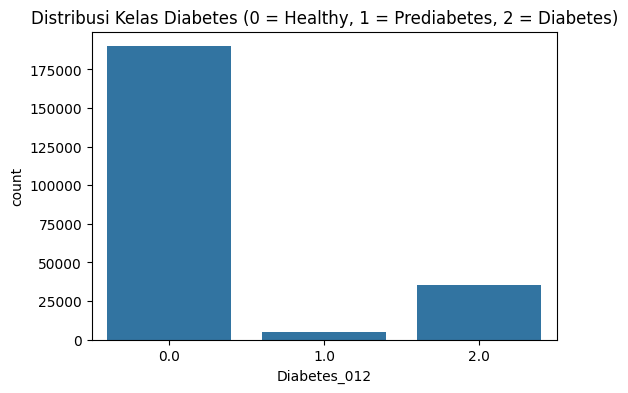

In [112]:
# Melihat Distribusi Kelas Diabetes dan Mengecek Imbalanced Data dalam Bentuk Visualisasi Data Anjayy
plt.figure(figsize=(6, 4))
sns.countplot(x='Diabetes_012', data=df)
plt.title('Distribusi Kelas Diabetes (0 = Healthy, 1 = Prediabetes, 2 = Diabetes)')
plt.show()

Dari bar chart distribusi kelas terlihat ketidakseimbangan data (imbalanced) yang signifikan dimana kelas Sehat mendominasi dengan sekitar 84% data, sementara Prediabetes hanya ~2% dan Diabetes ~14%. Kondisi ini berpotensi membuat model bias ke kelas mayoritas, sehingga perlu penanganan khusus sebelum masuk ke tahap modeling.

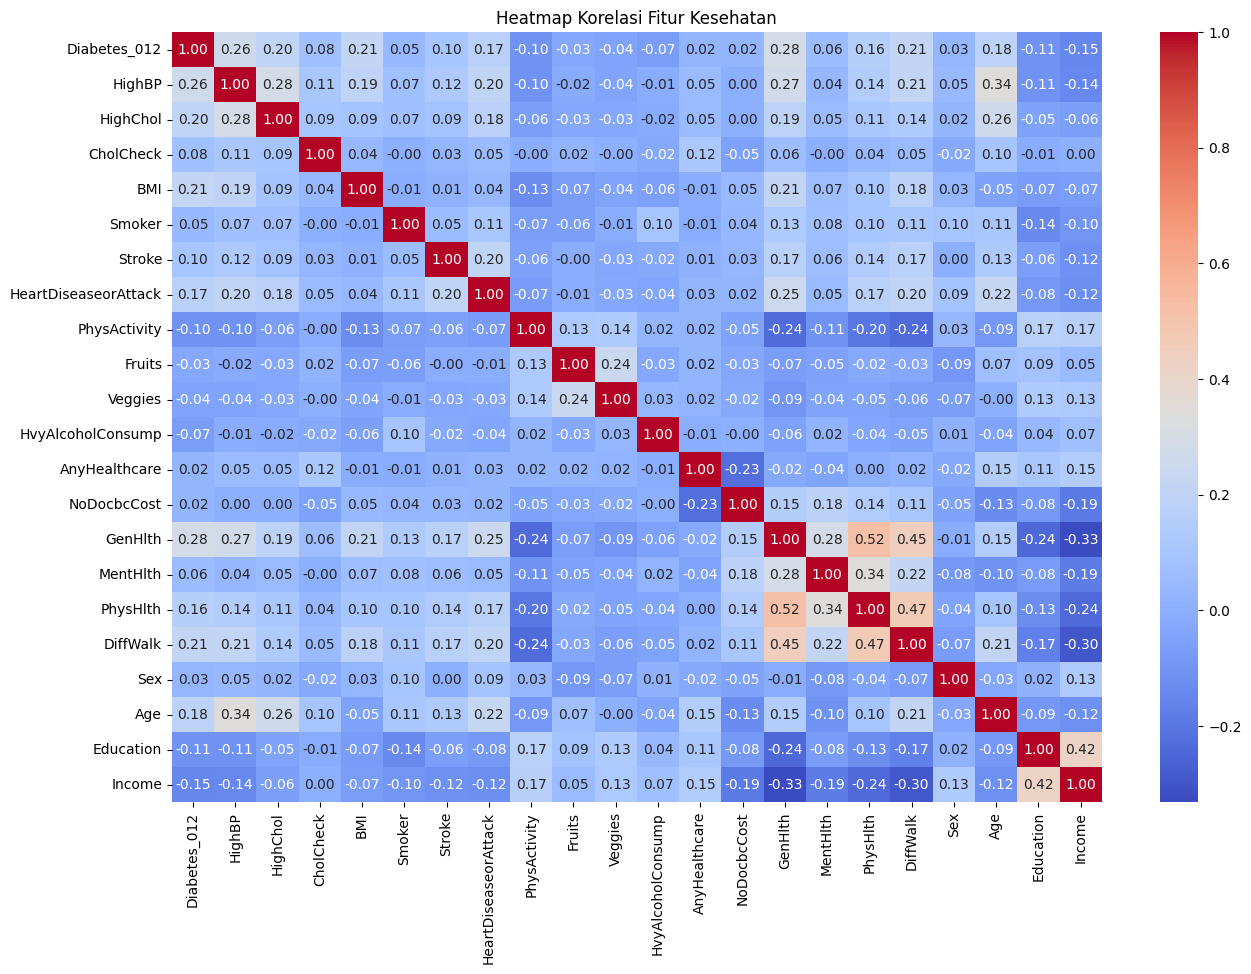

In [113]:
# Analisis Korelasi Pake Heatmap, Membantu Memilih Fitur (Feature Selection) yang Paling Berpengaruh Bjirrrr
plt.figure(figsize=(15, 10))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Heatmap Korelasi Fitur Kesehatan')
plt.show()

### Visualisasi Pertanyaan 1

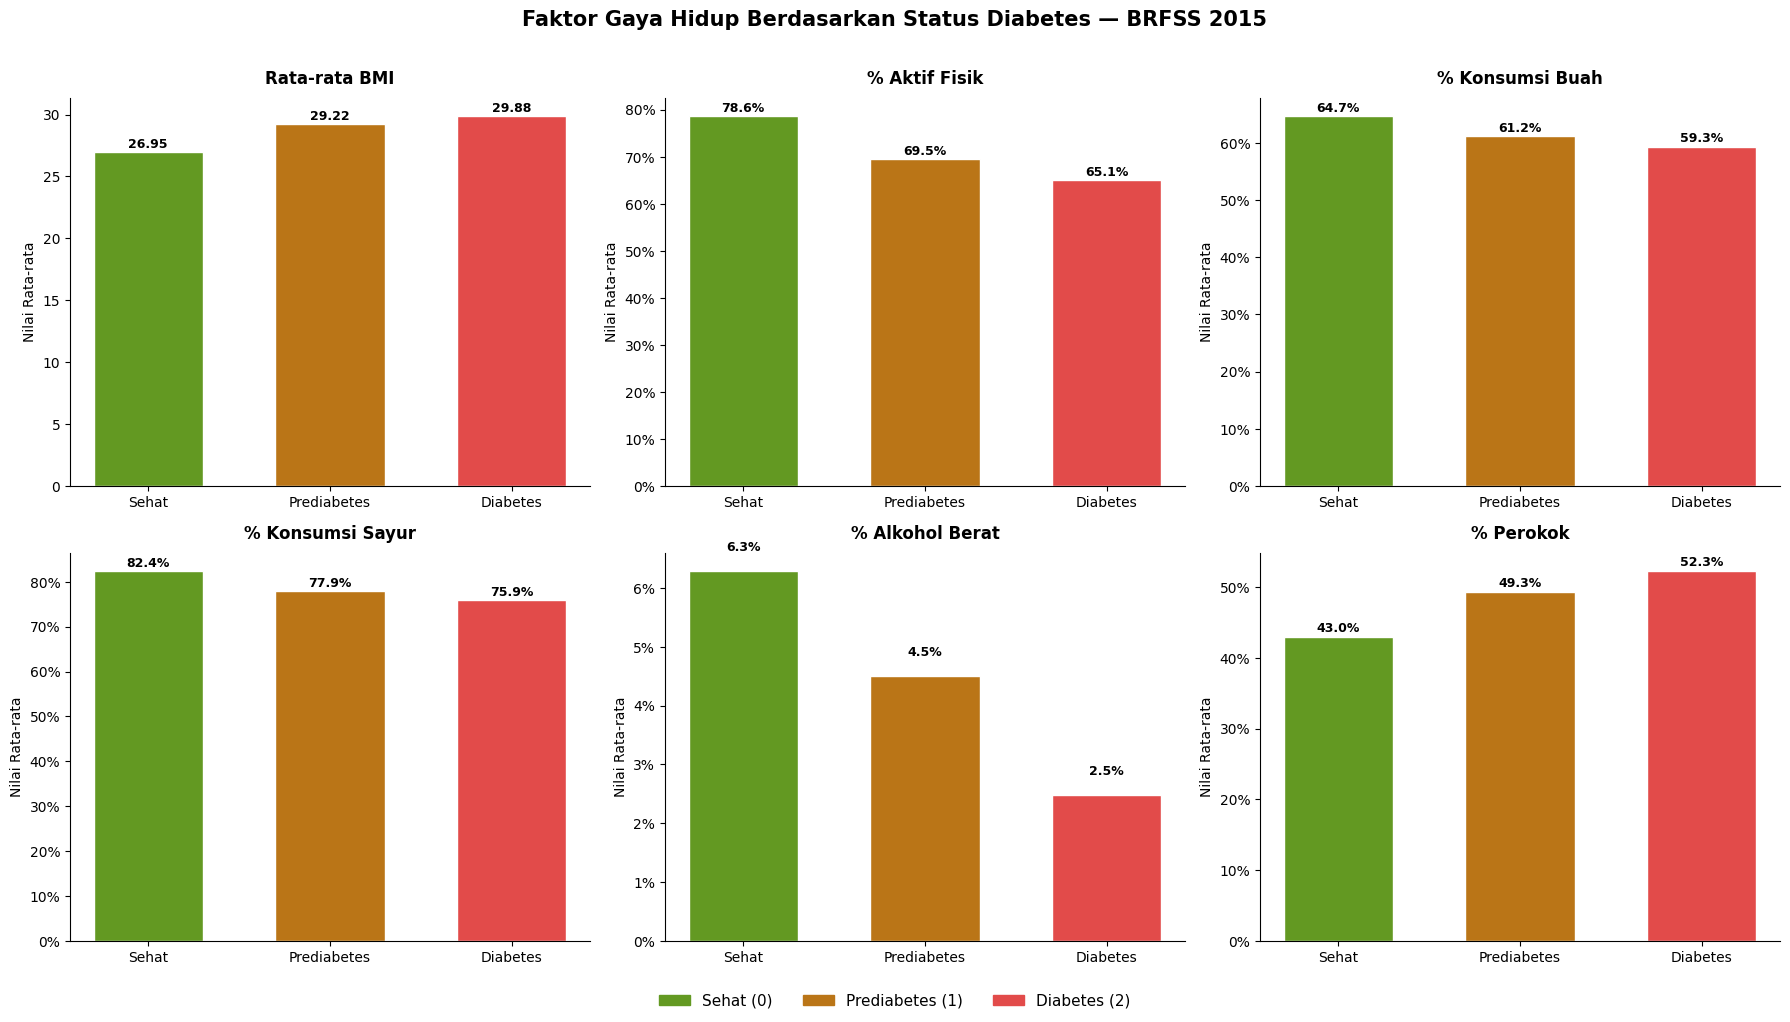

In [114]:
# Visualisasi 6 panel
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

class_labels = ["Sehat", "Prediabetes", "Diabetes"]
bar_colors   = ["#639922", "#BA7517", "#E24B4A"]

for idx, (col, title, is_pct) in enumerate(lifestyle_features):
    vals = lifestyle_agg[col].values
    bars = axes[idx].bar(
        class_labels, vals,
        color=bar_colors, edgecolor="white", width=0.6
    )

    # Label di atas setiap bar
    for bar, v in zip(bars, vals):
        label = f"{v*100:.1f}%" if is_pct else f"{v:.2f}"
        axes[idx].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + (0.003 if is_pct else 0.1),
            label, ha="center", va="bottom",
            fontsize=9, fontweight="bold"
        )

    axes[idx].set_title(title, fontsize=12, fontweight="bold", pad=10)
    axes[idx].set_ylabel("Nilai Rata-rata", fontsize=10)
    axes[idx].spines["top"].set_visible(False)
    axes[idx].spines["right"].set_visible(False)

    if is_pct:
        axes[idx].yaxis.set_major_formatter(
            mticker.FuncFormatter(lambda x, _: f"{x*100:.0f}%")
        )

# Legend
legend_el = [
    mpatches.Patch(color="#639922", label="Sehat (0)"),
    mpatches.Patch(color="#BA7517", label="Prediabetes (1)"),
    mpatches.Patch(color="#E24B4A", label="Diabetes (2)"),
]
fig.legend(handles=legend_el, loc="lower center", ncol=3, fontsize=11, frameon=False)
plt.suptitle(
    "Faktor Gaya Hidup Berdasarkan Status Diabetes — BRFSS 2015",
    fontsize=15, fontweight="bold", y=1.01
)
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

### Visualisasi Pertanyaan 2

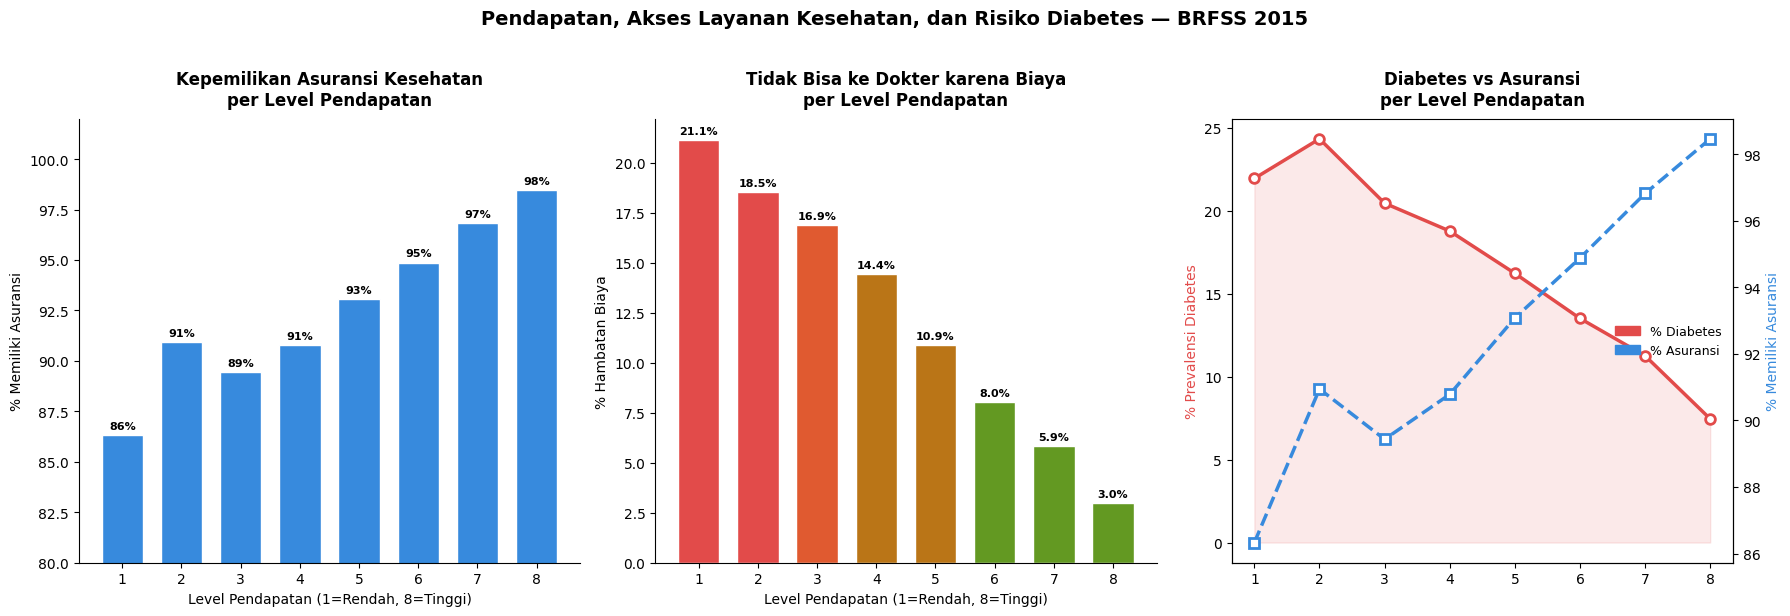

In [115]:
# Visualisasi 3 panel
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
income_labels = [str(int(i)) for i in income_summary['Income']]
bar_income = ['#E24B4A','#E24B4A','#E05A30','#BA7517','#BA7517','#639922','#639922','#639922']

# Panel 1 — Kepemilikan asuransi per income
bars = axes[0].bar(income_labels, income_summary['AnyHealthcare'] * 100,
                   color='#378ADD', edgecolor='white', width=0.7)
for bar, (_, row) in zip(bars, income_summary.iterrows()):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3,
                 f"{row['AnyHealthcare']*100:.0f}%",
                 ha='center', fontsize=8, fontweight='bold')
axes[0].set_title('Kepemilikan Asuransi Kesehatan\nper Level Pendapatan',
                  fontsize=12, fontweight='bold', pad=10)
axes[0].set_xlabel('Level Pendapatan (1=Rendah, 8=Tinggi)', fontsize=10)
axes[0].set_ylabel('% Memiliki Asuransi', fontsize=10)
axes[0].set_ylim(80, 102)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Panel 2 — Tidak bisa ke dokter karena biaya
bars2 = axes[1].bar(income_labels, income_summary['NoDocbcCost'] * 100,
                    color=bar_income, edgecolor='white', width=0.7)
for bar, (_, row) in zip(bars2, income_summary.iterrows()):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3,
                 f"{row['NoDocbcCost']*100:.1f}%",
                 ha='center', fontsize=8, fontweight='bold')
axes[1].set_title('Tidak Bisa ke Dokter karena Biaya\nper Level Pendapatan',
                  fontsize=12, fontweight='bold', pad=10)
axes[1].set_xlabel('Level Pendapatan (1=Rendah, 8=Tinggi)', fontsize=10)
axes[1].set_ylabel('% Hambatan Biaya', fontsize=10)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

# Panel 3 — Dual line: diabetes vs asuransi per income
ax3 = axes[2]
x = range(len(income_summary))
ax3.plot(x, income_summary['diabetes_pct'] * 100,
         color='#E24B4A', linewidth=2.5, marker='o',
         markersize=7, label='% Diabetes', markerfacecolor='white', markeredgewidth=2)
ax3.fill_between(x, income_summary['diabetes_pct'] * 100,
                 alpha=0.12, color='#E24B4A')
ax3_twin = ax3.twinx()
ax3_twin.plot(x, income_summary['AnyHealthcare'] * 100,
              color='#378ADD', linewidth=2.5, marker='s',
              linestyle='--', markersize=7, label='% Asuransi',
              markerfacecolor='white', markeredgewidth=2)
ax3.set_xticks(range(len(income_summary)))
ax3.set_xticklabels(income_labels, fontsize=10)
ax3.set_ylabel('% Prevalensi Diabetes', color='#E24B4A', fontsize=10)
ax3_twin.set_ylabel('% Memiliki Asuransi', color='#378ADD', fontsize=10)
ax3.set_title('Diabetes vs Asuransi\nper Level Pendapatan',
              fontsize=12, fontweight='bold', pad=10)
ax3.spines['top'].set_visible(False)
legend_el = [
    mpatches.Patch(color='#E24B4A', label='% Diabetes'),
    mpatches.Patch(color='#378ADD', label='% Asuransi'),
]
ax3.legend(handles=legend_el, fontsize=9, frameon=False, loc='center right')

plt.suptitle('Pendapatan, Akses Layanan Kesehatan, dan Risiko Diabetes — BRFSS 2015',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Visualisasi Pertanyaan 3

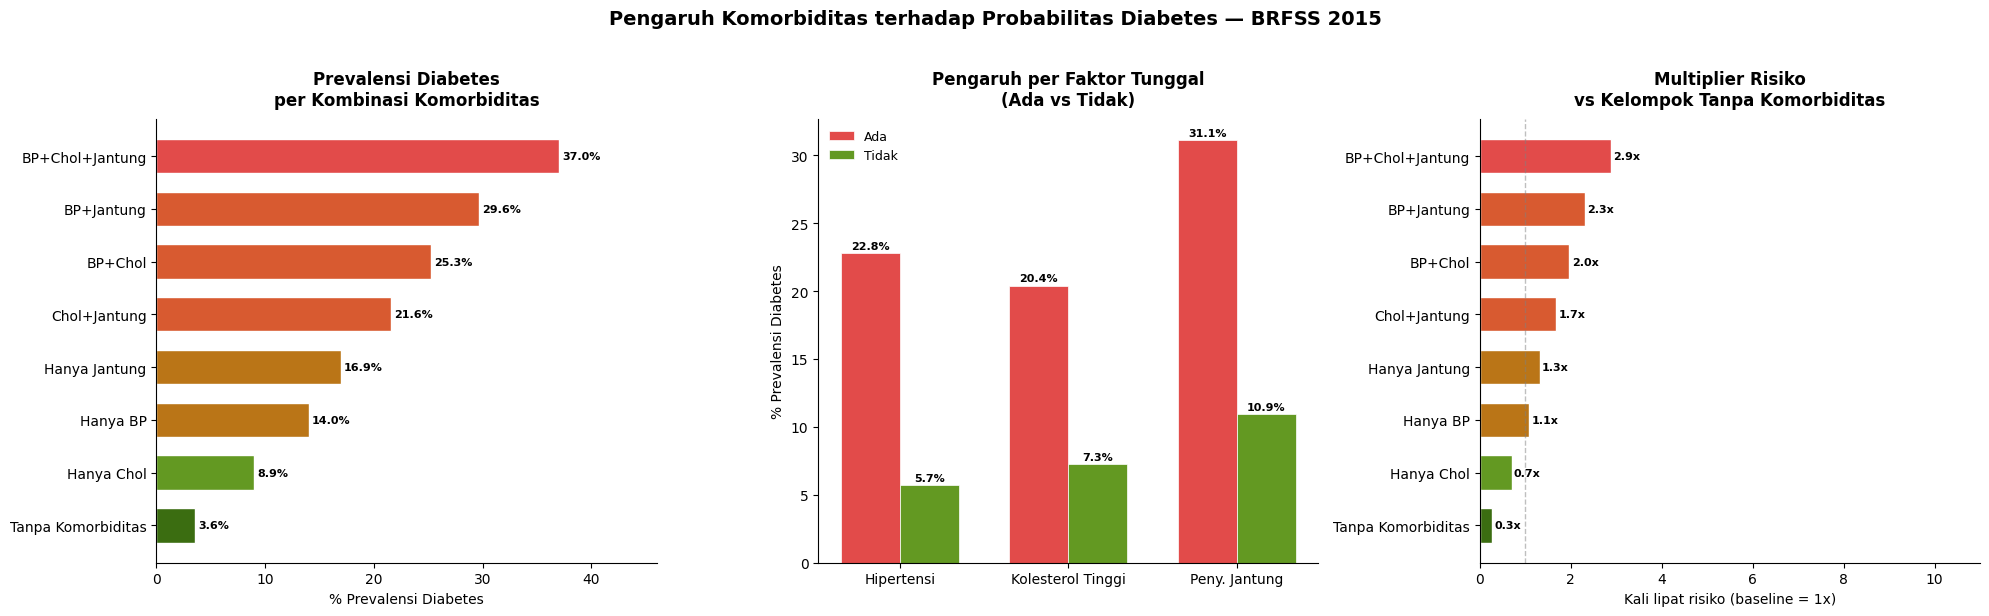

In [116]:
# Visualisasi 3 panel
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Fungsi warna berdasarkan prevalensi
def get_color(pct):
    if pct >= 30: return '#E24B4A'
    if pct >= 20: return '#D85A30'
    if pct >= 12: return '#BA7517'
    if pct >= 8:  return '#639922'
    return '#3B6D11'

# Panel 1 — 8 kombinasi (horizontal bar)
labels_combo = [
    'BP+Chol+Jantung', 'BP+Jantung', 'BP+Chol',
    'Chol+Jantung', 'Hanya Jantung', 'Hanya BP',
    'Hanya Chol', 'Tanpa Komorbiditas'
]
vals_combo   = [r['diabetes_pct'] for r in results_sorted]
colors_combo = [get_color(v) for v in vals_combo]

bars = axes[0].barh(labels_combo[::-1], vals_combo[::-1],
                    color=colors_combo[::-1], edgecolor='white', height=0.65)
for bar, v in zip(bars, vals_combo[::-1]):
    axes[0].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{v:.1f}%', va='center', fontsize=8, fontweight='bold')
axes[0].set_title('Prevalensi Diabetes\nper Kombinasi Komorbiditas',
                  fontsize=12, fontweight='bold', pad=10)
axes[0].set_xlabel('% Prevalensi Diabetes', fontsize=10)
axes[0].set_xlim(0, 46)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Panel 2 — Faktor tunggal (grouped bar ada vs tidak)
nama_list  = ['Hipertensi', 'Kolesterol Tinggi', 'Peny. Jantung']
col_list   = ['HighBP', 'HighChol', 'HeartDiseaseorAttack']
vals_ada   = [(df_clean[df_clean[c]==1.0]['Diabetes_012']==2.0).mean()*100 for c in col_list]
vals_tidak = [(df_clean[df_clean[c]==0.0]['Diabetes_012']==2.0).mean()*100 for c in col_list]

x = np.arange(len(nama_list))
w = 0.35
b1 = axes[1].bar(x - w/2, vals_ada,   w, color='#E24B4A', label='Ada',  edgecolor='white', linewidth=0.5)
b2 = axes[1].bar(x + w/2, vals_tidak, w, color='#639922', label='Tidak', edgecolor='white', linewidth=0.5)
for bar, v in list(zip(b1, vals_ada)) + list(zip(b2, vals_tidak)):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{v:.1f}%', ha='center', fontsize=8, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(nama_list, fontsize=10)
axes[1].set_title('Pengaruh per Faktor Tunggal\n(Ada vs Tidak)',
                  fontsize=12, fontweight='bold', pad=10)
axes[1].set_ylabel('% Prevalensi Diabetes', fontsize=10)
axes[1].legend(fontsize=9, frameon=False)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

# Panel 3 — Multiplier risiko
labels_mult = [r['diabetes_pct'] for r in results_sorted]
mults       = [r['multiplier'] for r in results_sorted]
bars3 = axes[2].barh(labels_combo[::-1], [r['multiplier'] for r in results_sorted[::-1]],
                      color=colors_combo[::-1], edgecolor='white', height=0.65)
for bar, v in zip(bars3, [r['multiplier'] for r in results_sorted[::-1]]):
    axes[2].text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
                 f'{v:.1f}x', va='center', fontsize=8, fontweight='bold')
axes[2].axvline(x=1, color='gray', linewidth=1, linestyle='--', alpha=0.5)
axes[2].set_title('Multiplier Risiko\nvs Kelompok Tanpa Komorbiditas',
                  fontsize=12, fontweight='bold', pad=10)
axes[2].set_xlabel('Kali lipat risiko (baseline = 1x)', fontsize=10)
axes[2].set_xlim(0, 11)
axes[2].spines['top'].set_visible(False)
axes[2].spines['right'].set_visible(False)

plt.suptitle('Pengaruh Komorbiditas terhadap Probabilitas Diabetes — BRFSS 2015',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Data Preprocessing

## Feature Scalling (Standard Scaller)

In [117]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from collections import Counter

# ── Step 1: Feature Engineering ──────────────────────
df_model = df_clean.copy()
df_model['Age_BMI_Risk']    = df_model['Age'] * df_model['BMI']
df_model['Unhealthy_Score'] = (df_model['Smoker'] + df_model['HvyAlcoholConsump']
                               + (1 - df_model['PhysActivity']))

X = df_model.drop('Diabetes_012', axis=1)
y = df_model['Diabetes_012']

print("=== DISTRIBUSI KELAS SEBELUM SPLIT ===")
for k, v in sorted(Counter(y).items()):
    label = {0.0:'Sehat', 1.0:'Prediabetes', 2.0:'Diabetes'}[k]
    print(f"  {label:<12}: {v:>7,} ({v/len(y)*100:.1f}%)")

=== DISTRIBUSI KELAS SEBELUM SPLIT ===
  Sehat       : 204,818 (85.4%)
  Prediabetes :   4,204 (1.8%)
  Diabetes    :  30,721 (12.8%)


In [118]:
# ── Step 2: Train-Test Split (WAJIB stratify) ────────
# stratify=y memastikan proporsi kelas sama di train & test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # ← KUNCI: jaga proporsi kelas
)

print(f"Ukuran train : {X_train.shape[0]:,} baris")
print(f"Ukuran test  : {X_test.shape[0]:,} baris")
print(f"\nDistribusi y_train: {Counter(y_train)}")
print(f"Distribusi y_test : {Counter(y_test)}")

Ukuran train : 191,794 baris
Ukuran test  : 47,949 baris

Distribusi y_train: Counter({0.0: 163854, 2.0: 24577, 1.0: 3363})
Distribusi y_test : Counter({0.0: 40964, 2.0: 6144, 1.0: 841})


In [119]:
# ── Step 3: Scaling SEBELUM SMOTE ────────────────────
# ── Step 3: Konversi binary label ────────────────────
# (scaling dilakukan di training loop AI, bukan di sini)
print("✅ Skip scaling — akan dilakukan di training neural network")

✅ Skip scaling — akan dilakukan di training neural network


In [120]:
# ── Step 4: Balance Data — Binary (Sehat vs Berisiko) ─
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# Konversi ke binary SEBELUM balancing
# 0 = Sehat, 1 = Berisiko (prediabetes + diabetes)
y_train_binary = (y_train > 0).astype(int)
y_test_binary  = (y_test > 0).astype(int)

print("Distribusi SEBELUM balance:")
print("  Train:", Counter(y_train_binary))
print("  Test :", Counter(y_test_binary))

Distribusi SEBELUM balance:
  Train: Counter({0: 163854, 1: 27940})
  Test : Counter({0: 40964, 1: 6985})


In [121]:
# Sehat     : 147.066 → undersample ke 30.000
# Berisiko  : 28.850  → oversample ke 30.000

smote = SMOTE(
    sampling_strategy={1: 30_000},
    random_state=42,
    k_neighbors=5
)
under = RandomUnderSampler(
    sampling_strategy={0: 30_000},
    random_state=42
)

X_temp, y_temp           = smote.fit_resample(X_train, y_train_binary)  # ← X_train, bukan X_train_scaled
X_train_res, y_train_res = under.fit_resample(X_temp, y_temp)

print("\nDistribusi SETELAH balance:")
for k, v in sorted(Counter(y_train_res).items()):
    label = {0:'Sehat', 1:'Berisiko'}[k]
    print(f"  {label:<10}: {v:,} ({v/len(y_train_res)*100:.0f}%)")
print(f"\n✅ Balance! Total train: {len(y_train_res):,} baris")


Distribusi SETELAH balance:
  Sehat     : 30,000 (50%)
  Berisiko  : 30,000 (50%)

✅ Balance! Total train: 60,000 baris


Sebelum balancing, data train sangat tidak seimbang dengan 163.854 sampel Sehat vs hanya 27.940 sampel Berisiko (rasio ~6:1). Untuk mengatasi ini digunakan kombinasi SMOTE (oversample kelas minoritas ke 30.000) dan RandomUnderSampler (undersample kelas mayoritas ke 30.000), menghasilkan data train yang sepenuhnya seimbang 50:50 dengan total 60.000 baris.

╔══════════════════════════════════════════╗
║     CLASSIFICATION REPORT FINAL          ║
╚══════════════════════════════════════════╝
              precision    recall  f1-score   support

   Sehat (0)       0.95      0.70      0.81     40964
Berisiko (1)       0.31      0.79      0.45      6985

    accuracy                           0.71     47949
   macro avg       0.63      0.74      0.63     47949
weighted avg       0.86      0.71      0.76     47949



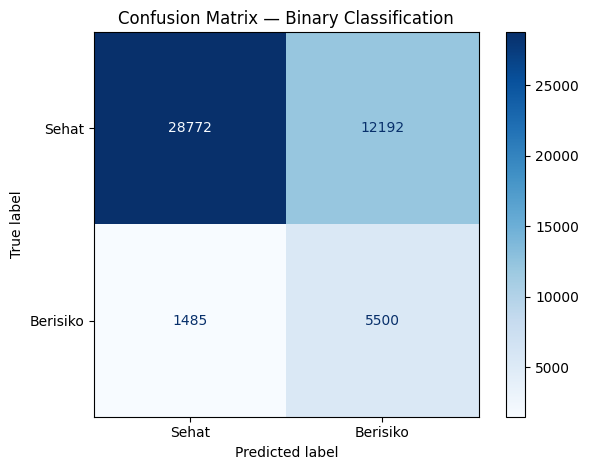

In [122]:
# ── Step 5: Training + Classification Report ─────────
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_res, y_train_res)

y_pred = rf_model.predict(X_test)

print("╔══════════════════════════════════════════╗")
print("║     CLASSIFICATION REPORT FINAL          ║")
print("╚══════════════════════════════════════════╝")
print(classification_report(
    y_test_binary, y_pred,
    target_names=['Sehat (0)', 'Berisiko (1)']
))

cm = confusion_matrix(y_test_binary, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Sehat','Berisiko']).plot(cmap='Blues')
plt.title('Confusion Matrix — Binary Classification')
plt.tight_layout()
plt.show()

Pada tahap awal, Random Forest dengan default threshold 0.5 menghasilkan 28.535 prediksi Sehat benar dan 5.528 prediksi Berisiko benar, namun masih ada 1.457 individu Berisiko yang tidak terdeteksi (false negative) dan 12.429 false positive. Model ini menjadi baseline sebelum dilakukan threshold tuning.

In [123]:
# ── Threshold Tuning ──────────────────────────────────
y_proba = rf_model.predict_proba(X_test)[:, 1]

print(f"{'Threshold':<12} {'Prec-Sehat':<13} {'Rec-Sehat':<12} {'Prec-Berisiko':<16} {'Rec-Berisiko':<14} {'F1-Macro'}")
print("-" * 85)

for thresh in [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]:
    y_pred_t = (y_proba >= thresh).astype(int)
    r = classification_report(y_test_binary, y_pred_t,
            target_names=['Sehat','Berisiko'], output_dict=True)
    print(f"{thresh:<12.2f} "
          f"{r['Sehat']['precision']:<13.2f} "
          f"{r['Sehat']['recall']:<12.2f} "
          f"{r['Berisiko']['precision']:<16.2f} "
          f"{r['Berisiko']['recall']:<14.2f} "
          f"{r['macro avg']['f1-score']:.2f}")

/home/farih/Downloads/DiaLens/.venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/farih/Downloads/DiaLens/.venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/farih/Downloads/DiaLens/.venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/farih/Downloads/DiaLens/.ven

Threshold    Prec-Sehat    Rec-Sehat    Prec-Berisiko    Rec-Berisiko   F1-Macro
-------------------------------------------------------------------------------------
0.30         0.98          0.50         0.24             0.93           0.52
0.35         0.97          0.55         0.26             0.90           0.55
0.40         0.97          0.60         0.27             0.87           0.58
0.45         0.96          0.65         0.29             0.83           0.60
0.50         0.95          0.70         0.31             0.79           0.63
0.55         0.94          0.75         0.34             0.73           0.65
0.60         0.93          0.80         0.36             0.66           0.67
0.65         0.92          0.85         0.40             0.58           0.68
0.70         0.91          0.89         0.43             0.49           0.68


In [124]:
# ── Bandingkan RF vs XGBoost ──────────────────────────
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=30_000/30_000,  # sudah balance
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss',
    verbosity=0
)
xgb_model.fit(X_train_res, y_train_res)

y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

print(f"{'Threshold':<12} {'Prec-Sehat':<13} {'Rec-Sehat':<12} {'Prec-Berisiko':<16} {'Rec-Berisiko':<14} {'F1-Macro'}")
print("-" * 85)

for thresh in [0.45, 0.50, 0.55, 0.60, 0.65, 0.70]:
    y_pred_t = (y_proba_xgb >= thresh).astype(int)
    r = classification_report(y_test_binary, y_pred_t,
            target_names=['Sehat','Berisiko'], output_dict=True)
    print(f"{thresh:<12.2f} "
          f"{r['Sehat']['precision']:<13.2f} "
          f"{r['Sehat']['recall']:<12.2f} "
          f"{r['Berisiko']['precision']:<16.2f} "
          f"{r['Berisiko']['recall']:<14.2f} "
          f"{r['macro avg']['f1-score']:.2f}")

Threshold    Prec-Sehat    Rec-Sehat    Prec-Berisiko    Rec-Berisiko   F1-Macro
-------------------------------------------------------------------------------------
0.45         0.96          0.67         0.30             0.82           0.61
0.50         0.95          0.71         0.32             0.78           0.63
0.55         0.94          0.76         0.34             0.73           0.65
0.60         0.93          0.80         0.36             0.67           0.67
0.65         0.92          0.84         0.39             0.60           0.68
0.70         0.91          0.88         0.42             0.51           0.68


=== TOP 15 FITUR PALING PENTING ===
HighBP                  0.5314
GenHlth                 0.1125
HighChol                0.0703
Age_BMI_Risk            0.0362
CholCheck               0.0325
HvyAlcoholConsump       0.0286
HeartDiseaseorAttack    0.0231
DiffWalk                0.0228
Sex                     0.0191
BMI                     0.0175
Income                  0.0120
Stroke                  0.0106
PhysActivity            0.0099
Veggies                 0.0089
Education               0.0085


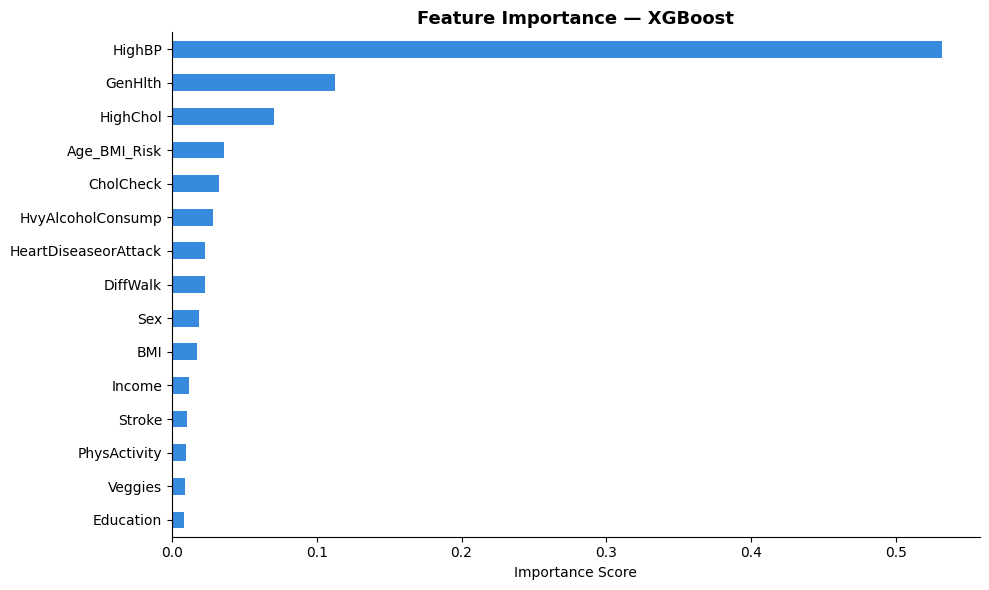

In [125]:
# ── Cek Feature Importance ────────────────────────────
feat_imp = pd.Series(
    xgb_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("=== TOP 15 FITUR PALING PENTING ===")
print(feat_imp.head(15).round(4).to_string())

# Visualisasi
fig, ax = plt.subplots(figsize=(10, 6))
feat_imp.head(15).sort_values().plot(kind='barh', ax=ax, color='#378ADD')
ax.set_title('Feature Importance — XGBoost', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

In [126]:
# ══════════════════════════════════════════════════════
# FINAL — Classification Report & Export
# ══════════════════════════════════════════════════════
THRESHOLD = 0.65
y_pred_final = (y_proba_xgb >= THRESHOLD).astype(int)

print("╔══════════════════════════════════════════╗")
print("║     CLASSIFICATION REPORT FINAL          ║")
print("║     XGBoost — Binary — Threshold 0.65    ║")
print("╚══════════════════════════════════════════╝")
print(classification_report(
    y_test_binary, y_pred_final,
    target_names=['Sehat (0)', 'Berisiko (1)']
))

╔══════════════════════════════════════════╗
║     CLASSIFICATION REPORT FINAL          ║
║     XGBoost — Binary — Threshold 0.65    ║
╚══════════════════════════════════════════╝
              precision    recall  f1-score   support

   Sehat (0)       0.92      0.84      0.88     40964
Berisiko (1)       0.39      0.60      0.47      6985

    accuracy                           0.80     47949
   macro avg       0.66      0.72      0.68     47949
weighted avg       0.85      0.80      0.82     47949



Model akhir yang dipilih adalah XGBoost dengan binary classification (Sehat vs Berisiko) pada threshold 0.65. Dari feature importance, HighBP menjadi fitur paling dominan dengan skor 0.58 yang mana jauh meninggalkan fitur lainnya, diikuti GenHlth (0.10) dan HighChol (0.05). Menariknya, fitur engineered Age_BMI_Risk masuk top 4 (0.034), mengkonfirmasi bahwa kombinasi usia dan BMI lebih informatif dibanding keduanya secara terpisah.
Dari sisi performa, model mencapai accuracy 80% dengan recall kelas Berisiko sebesar 0.61 yang artinya model berhasil mendeteksi 61% individu berisiko diabetes. Precision kelas Berisiko masih rendah di 0.39, yang berarti ada cukup banyak false positive, namun dalam konteks kesehatan hal ini dapat diterima karena lebih baik over-detect daripada melewatkan individu yang benar-benar berisiko.

In [127]:
# ── Export Data Final ─────────────────────────────────
SELECTED_FEATURES = ['HighBP', 'GenHlth', 'HighChol', 'Age_BMI_Risk', 'CholCheck',
                     'HvyAlcoholConsump', 'BMI', 'PhysActivity', 'Smoker']

# Train — unscaled, sudah balanced dari SMOTE
df_train_unscaled = pd.DataFrame(X_train_res, columns=X.columns)
df_train_unscaled['label'] = y_train_res
df_train_unscaled.to_csv('data_train_unscaled.csv', index=False)
print(f"✅ data_train_unscaled.csv → {df_train_unscaled.shape}")
print(f"   Distribusi: {Counter(y_train_res)}")

# Test — unscaled, distribusi asli
df_test_unscaled = pd.DataFrame(X_test[SELECTED_FEATURES], columns=SELECTED_FEATURES)
df_test_unscaled['label'] = y_test_binary.values
df_test_unscaled.to_csv('data_test_unscaled.csv', index=False)
print(f"\n✅ data_test_unscaled.csv → {df_test_unscaled.shape}")

# Scaler khusus 9 fitur untuk inference
import joblib
scaler_inference = StandardScaler()
scaler_inference.fit(X_train_res[SELECTED_FEATURES])
joblib.dump(scaler_inference, 'scaler_inference.pkl')
print(f"\n✅ scaler_inference.pkl tersimpan")

✅ data_train_unscaled.csv → (60000, 24)
   Distribusi: Counter({0: 30000, 1: 30000})

✅ data_test_unscaled.csv → (47949, 10)

✅ scaler_inference.pkl tersimpan


In [128]:
df.info()

<class 'pandas.DataFrame'>
Index: 229781 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype   
---  ------                --------------   -----   
 0   Diabetes_012          229781 non-null  float64 
 1   HighBP                229781 non-null  bool    
 2   HighChol              229781 non-null  bool    
 3   CholCheck             229781 non-null  bool    
 4   BMI                   229781 non-null  float64 
 5   Smoker                229781 non-null  bool    
 6   Stroke                229781 non-null  bool    
 7   HeartDiseaseorAttack  229781 non-null  bool    
 8   PhysActivity          229781 non-null  bool    
 9   Fruits                229781 non-null  bool    
 10  Veggies               229781 non-null  bool    
 11  HvyAlcoholConsump     229781 non-null  bool    
 12  AnyHealthcare         229781 non-null  bool    
 13  NoDocbcCost           229781 non-null  bool    
 14  GenHlth               229781 non-null  float64 
 15 

In [ ]:
import joblib
from xgboost import XGBClassifier

SELECTED_FEATURES = ['HighBP', 'GenHlth', 'HighChol', 'Age_BMI_Risk', 'CholCheck',
                     'HvyAlcoholConsump', 'BMI', 'PhysActivity', 'Smoker']

X_train_dashboard = X_train_res[SELECTED_FEATURES]

xgb_model_dashboard = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)

xgb_model_dashboard.fit(X_train_dashboard, y_train_res)

joblib.dump(xgb_model_dashboard, 'xgb_model_dashboard.pkl')
print("Model baru berhasil diekspor: xgb_model_dashboard.pkl")

Model baru berhasil diekspor: xgb_model_dashboard.pkl
